DUVIDAS \
1.no kaggle diz que a key é o unique identifyer mas entao o que é a primeira coluna e podemos apagar a key pq é igual á outra \
2.lidar com os null fare values
3. apagamos os negative fare amounts?

<div style="background-color:#EFF5FF; padding:20px; border-radius:10px; border-left:8px solid #0047AB;">

<h1 style="margin-bottom:0;"><b> Machine Learning II - Project 1</b></h1>
<br>

<h1 style="margin-top:5px; color:#0047AB;"><b>"Uber Fares" </b></h1>

<h2 style="color:#0047AB; margin-top:-5px;"><b>Data Preprocessing & Exploratory Analysis</b></h2>


<h3><b> Group _o melhor muahahahha (malefico) </b></h3>
    
<b>Carlota Marto</b> — 20241729</li>\
<b>Francisca Teixeira</b> — 20241702</li>
</ul>
<h4>LCD  —  Teachers: Ivo Bernardo  — 2025/26 </h4>

</div>


<div style="background-color:#EFF5FF; padding:15px; border-radius:10px;">

**Table of Contents**

**1.Introduction**

1.1. Project Context and Goal

**Part A – Data Understanding & Cleaning**

2.1. Imports\
2.2. Preprocessing Data
<ul style="margin-top:-10px;">
    
  2.2.1. Duplicate Records \
  2.2.2  Handling Inconsistencies \
  2.2.3. Missing Values - Categorical(3) / Numerical (3)\
  2.2.4. Outliers  \
  2.2.5. Adjusting Data Types 
</ul>

**Part B – Feature Engineering & ABT Construction**

3.1. Static attributes (demographics)\
3.2. Aggregated behavior from all visits\
3.3. Recency & activity\
3.4.  ABT exportation


**Part C – Exploratory Visualization & Insights**

4.1.  Uber demographics: Age, Gender, and income
distributions\
4.2. Department & Service Usage\
4.3. Satisfaction: Department and Patient Segment \
4.4. Other plots 

<div style="background-color:#EFF5FF; padding:20px; border-radius:10px; border-left:8px solid #0047AB;">
<h3><b>1. Introduction </b></h3>


 <div style="background-color:#EFF5FF; padding:20px; border-radius:10px; border-left:8px">
<b> 1.1. Project Context and Goal

Introduction to Uber's Challenge: Explore how Uber's massive daily operations necessitate accurate fare prediction for optimal business strategies.

<div style="background-color:#EFF5FF; padding:20px; border-radius:10px; border-left:8px solid #0047AB;">
<h3><b>Part A – Data Understanding & Cleaning </b></h3>

<div style="background-color:#EFF5FF; padding:20px; border-radius:10px; border-left:8px">
<b>2.1 Imports

Import of Necessary Libraries:

In [29]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

Import of the given Dataset:

In [30]:
df = pd.read_csv('uber.csv', index_col = 0)
print("The dataset has {} rows and {} columns".format(df.shape[0], df.shape[1]))
df.head()

The dataset has 200000 rows and 8 columns


,key,fare_amount,pickup_datetime,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count
24238194,2015-05-07 19:52:06.0000003,7.5,2015-05-07 19:52:06 UTC,-73.999817,40.738354,-73.999512,40.723217,1
27835199,2009-07-17 20:04:56.0000002,7.7,2009-07-17 20:04:56 UTC,-73.994355,40.728225,-73.994710,40.750325,1
44984355,2009-08-24 21:45:00.00000061,12.9,2009-08-24 21:45:00 UTC,-74.005043,40.740770,-73.962565,40.772647,1
25894730,2009-06-26 08:22:21.0000001,5.3,2009-06-26 08:22:21 UTC,-73.976124,40.790844,-73.965316,40.803349,3
17610152,2014-08-28 17:47:00.000000188,16.0,2014-08-28 17:47:00 UTC,-73.925023,40.744085,-73.973082,40.761247,5


**Atributes description:** \
**key:** Unique trip identifier.\
**fare_amount:** Cost of trip (in USD).\
**pickup_datetime:** Timestamp of trip start.\
**passenger_count:** Number of passengers.\
**pickup_longitude & pickup_latitude:** Initial pickup coordinates.\
**dropoff_longitude & dropoff_latitude:** Drop-off coordinates.

<div style="background-color:#0047AB; padding:20px; border-radius:10px; border-left:8px">

<div style="background-color:#EFF5FF; padding:20px; border-radius:10px; border-left:8px">
<b>2.2. Preprocessing Data
   

<div style="background-color:#EFF5FF; padding:20px; border-radius:10px; border-left:8px">
<b>2.2.1. How to Handle Duplicate Records

We chose to handle the **duplicate records firstly** so that those records do not interfere with the imputation of the missing values.

In [31]:
duplicate_records = df[df.duplicated(keep = False)]
duplicate_records.shape
#these two lines shows us the duplicate records in the dataset

(0, 8)

There aren´t duplicate records.

<div style="background-color:#EFF5FF; padding:20px; border-radius:10px; border-left:8px">
<b>2.2.2. Handling Inconsistent Records

Datasets frequently contain logical inconsistencies (for instance, negative money). These records are technically present in the dataset but do not make any sense in a real-world context. This step is dedicated to identifying and correcting these errors, which are different from missing data.

We chose to handle these inconsistencies before the imputation of the missing values as we often use conditional imputation and, if they are left uncorrected, it distorts the groups statistics, such as the median, mean or mode. So in this way we ensure that the statistical basis is clean, stable and accurate.

<div style="background-color:#EFF5FF; padding:20px; border-radius:10px; border-left:8px">
<b> Our Solution: </b>

We cannot just check the records one by one until we find some inconsistency. Instead, we will define **simple, logical rules** (for example, one has to be at least 18 years old to have a job) that the computer will use to instantly identify **every incorrect record**. This approach is essential because it allows us to find all problem rows with a single, fast query, even in a dataset with billions of records. 

This is a **simple** and **fast** way to check every record of the dataset. After every incorrect record is identified, we will then proceed to **analyse every case** marked as "not valid" and find the best way to deal with it.

In [32]:
df.head()

,key,fare_amount,pickup_datetime,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count
24238194,2015-05-07 19:52:06.0000003,7.5,2015-05-07 19:52:06 UTC,-73.999817,40.738354,-73.999512,40.723217,1
27835199,2009-07-17 20:04:56.0000002,7.7,2009-07-17 20:04:56 UTC,-73.994355,40.728225,-73.994710,40.750325,1
44984355,2009-08-24 21:45:00.00000061,12.9,2009-08-24 21:45:00 UTC,-74.005043,40.740770,-73.962565,40.772647,1
25894730,2009-06-26 08:22:21.0000001,5.3,2009-06-26 08:22:21 UTC,-73.976124,40.790844,-73.965316,40.803349,3
17610152,2014-08-28 17:47:00.000000188,16.0,2014-08-28 17:47:00 UTC,-73.925023,40.744085,-73.973082,40.761247,5


The column 'key' doesn´t add info necessary (is the same time as pickup_datetime with millisecond).

In [33]:
df.drop(columns='key', inplace=True)
df

,fare_amount,pickup_datetime,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count
24238194,7.5,2015-05-07 19:52:06 UTC,-73.999817,40.738354,-73.999512,40.723217,1
27835199,7.7,2009-07-17 20:04:56 UTC,-73.994355,40.728225,-73.994710,40.750325,1
44984355,12.9,2009-08-24 21:45:00 UTC,-74.005043,40.740770,-73.962565,40.772647,1
25894730,5.3,2009-06-26 08:22:21 UTC,-73.976124,40.790844,-73.965316,40.803349,3
17610152,16.0,2014-08-28 17:47:00 UTC,-73.925023,40.744085,-73.973082,40.761247,5
...,...,...,...,...,...,...,...
42598914,3.0,2012-10-28 10:49:00 UTC,-73.987042,40.739367,-73.986525,40.740297,1
16382965,7.5,2014-03-14 01:09:00 UTC,-73.984722,40.736837,-74.006672,40.739620,1
27804658,30.9,2009-06-29 00:42:00 UTC,-73.986017,40.756487,-73.858957,40.692588,2
20259894,14.5,2015-05-20 14:56:25 UTC,-73.997124,40.725452,-73.983215,40.695415,1


<div style="background-color:#EFF5FF; padding:20px; border-radius:10px; border-left:8px">
2.2.2. Handling Inconsistent Records <b>- First Rule: Negative Values - Every variable that corresponds to a price, time or number of passagers cannot be negative.

<div style="background-color:#EFF5FF; padding:20px; border-radius:10px; border-left:8px solid #0047AB;">
    
**Price** - fare_amount

<div style="background-color:#EFF5FF; padding:20px; border-radius:10px; border-left:8px">
Null Values: 

In [34]:
null_fares = df[df['fare_amount'] == 0]
null_fares

,fare_amount,pickup_datetime,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count
25344154,0.0,2015-04-22 23:25:07 UTC,-73.658897,40.805199,-73.658897,40.805199,1
22994576,0.0,2010-03-20 02:59:51 UTC,-73.994366,40.755395,-73.998718,40.854853,2
10649069,0.0,2015-01-04 03:51:13 UTC,-73.969475,40.807503,0.000000,0.000000,2
36776406,0.0,2015-02-17 08:48:08 UTC,-73.937714,40.758541,-73.937721,40.758541,1
44172118,0.0,2015-02-13 07:35:32 UTC,0.000000,0.000000,0.000000,0.000000,5


- **25344154** - pickup and dropoff travel coordinates are the same so we consider it was a **canceled uber**. It is not an error it is just a travel that didn´t occur. 
- **22994576** - travel occur - **error**. We can estimate the fare amount.
- **10649069** - dropoff_longitude and dropoff_latitude are both 0.0. We consider an **error** because all of the other observations are in the same zone and not travel half world. We cannot estimate the fare amount.
- **36776406** - pickup_latitude and dropoff_latitude	are the same and pickup_longitude and dropoff_longitude have a 0.000007 difference so we consider that was a **canceled travel.**
- **44172118** - the other values are all in the same zone (near -73 longitude, 40 latitude), so we consider the 0.0 a **error** and not a canceled travel with coordinates 0.0. We cannot estimate the fare amount.

Droping errors and mantaining canceled travels:

In [35]:
df.drop([10649069, 44172118], axis=0, inplace=True)

<div style="background-color:#EFF5FF; padding:20px; border-radius:10px; border-left:8px">
Calculating Distances:

For travel nº22994576 - caultulating the travel distance for all and seeing what travel has the most parecida distance and datetime.

**Function to transform coordinates to distance:** new column

In [36]:
def haversine_distance(lat1, lon1, lat2, lon2):
    r = 6371 # Raio da Terra em km
    phi1, phi2 = np.radians(lat1), np.radians(lat2)
    dphi = np.radians(lat2 - lat1)
    dlambda = np.radians(lon2 - lon1)
    
    a = np.sin(dphi/2)**2 + np.cos(phi1) * np.cos(phi2) * np.sin(dlambda/2)**2
    res = 2 * r * np.arcsin(np.sqrt(a))
    return res

In [37]:
df['distance_km'] = haversine_distance(df['pickup_latitude'], df['pickup_longitude'], df['dropoff_latitude'], df['dropoff_longitude'])
df

,fare_amount,pickup_datetime,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count,distance_km
24238194,7.5,2015-05-07 19:52:06 UTC,-73.999817,40.738354,-73.999512,40.723217,1,1.683323
27835199,7.7,2009-07-17 20:04:56 UTC,-73.994355,40.728225,-73.994710,40.750325,1,2.457590
44984355,12.9,2009-08-24 21:45:00 UTC,-74.005043,40.740770,-73.962565,40.772647,1,5.036377
25894730,5.3,2009-06-26 08:22:21 UTC,-73.976124,40.790844,-73.965316,40.803349,3,1.661683
17610152,16.0,2014-08-28 17:47:00 UTC,-73.925023,40.744085,-73.973082,40.761247,5,4.475450
...,...,...,...,...,...,...,...,...
42598914,3.0,2012-10-28 10:49:00 UTC,-73.987042,40.739367,-73.986525,40.740297,1,0.112210
16382965,7.5,2014-03-14 01:09:00 UTC,-73.984722,40.736837,-74.006672,40.739620,1,1.875050
27804658,30.9,2009-06-29 00:42:00 UTC,-73.986017,40.756487,-73.858957,40.692588,2,12.850319
20259894,14.5,2015-05-20 14:56:25 UTC,-73.997124,40.725452,-73.983215,40.695415,1,3.539715


In [38]:
#Reference Values:
travel_ref = df.loc[22994576]
dist_ref = travel_ref['distance_km']
time_ref = pd.to_datetime(travel_ref['pickup_datetime'])

In [39]:
#absolute diff of distance
df_busca = df.drop(index=22994576)
df_busca['diff_dist'] = (df_busca['distance_km'] - dist_ref).abs()

In [40]:
#5 travels with diff_dist more small
top_5_dist = df_busca.nsmallest(5, 'diff_dist').copy()
top_5_dist

,fare_amount,pickup_datetime,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count,distance_km,diff_dist
47542165,26.10,2012-01-06 23:28:00 UTC,-73.863085,40.768505,-73.984370,40.730335,2,11.063343,0.001947
12576258,40.33,2013-09-30 21:28:01 UTC,-73.874473,40.774075,-73.979000,40.713778,1,11.067830,0.002540
27876322,31.00,2014-09-29 14:49:26 UTC,-73.983736,40.721465,-73.872381,40.774294,1,11.068077,0.002788
7385134,37.83,2014-12-05 13:59:58 UTC,-73.862820,40.768896,-73.983818,40.730086,1,11.068562,0.003272
29823507,7.30,2012-07-15 04:48:00 UTC,-73.973625,40.755062,-73.912167,40.843065,3,11.068791,0.003502


We will choose the fare amount of **47542165** to input in **22994576** because is the travel with travel distance more similar, and the second with pickup_datetime more close.

In [41]:
df.at[22994576, 'fare_amount'] = 26.10

In [42]:
df[df.index==22994576]

,fare_amount,pickup_datetime,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count,distance_km
22994576,26.1,2010-03-20 02:59:51 UTC,-73.994366,40.755395,-73.998718,40.854853,2,11.065289


<div style="background-color:#EFF5FF; padding:20px; border-radius:10px; border-left:8px">
Negative Fare Amount:

In [43]:
negative_fares = ['fare_amount']
df[((df[negative_fares]) < 0).any(axis=1)]

,fare_amount,pickup_datetime,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count,distance_km
30260042,-5.00,2015-03-03 23:07:41 UTC,-73.992249,40.748936,-73.988518,40.748180,1,0.325306
51325304,-3.30,2010-02-11 21:47:10 UTC,-73.952725,40.768235,-73.949928,40.772208,2,0.500646
50284253,-3.50,2015-05-01 14:43:02 UTC,-73.982430,40.775024,-73.981750,40.778439,1,0.383918
26673143,-49.57,2010-03-09 08:26:10 UTC,-73.972772,40.785657,-73.972867,40.785500,5,0.019203
10267585,-23.70,2010-03-12 08:49:10 UTC,-73.952740,40.768233,-74.007028,40.707338,3,8.171296
51135168,-52.00,2015-03-20 21:31:14 UTC,-74.000359,40.728729,-74.005699,40.728680,5,0.450054
21688700,-7.30,2010-03-09 20:25:10 UTC,-73.952623,40.766942,-73.953787,40.784882,1,1.997243
13971251,-52.00,2015-02-23 19:26:44 UTC,-73.984665,40.759026,0.000000,0.000000,5,8666.246939
40714150,-6.90,2010-02-23 18:52:10 UTC,-73.988727,40.736445,-73.977622,40.750487,1,1.820225
34933571,-5.70,2010-02-12 10:50:10 UTC,-73.977300,40.742783,-73.988837,40.747465,3,1.102572


In [44]:
df[((df[negative_fares]) < 0).any(axis=1)].shape[0]

17

We cannot know if it is a mistake, if the real value is equal but positive, so we delete.

In [45]:
df[((df[negative_fares]) < 0).any(axis=1)].drop

<bound method DataFrame.drop of           fare_amount          pickup_datetime  pickup_longitude  \
30260042        -5.00  2015-03-03 23:07:41 UTC        -73.992249   
51325304        -3.30  2010-02-11 21:47:10 UTC        -73.952725   
50284253        -3.50  2015-05-01 14:43:02 UTC        -73.982430   
26673143       -49.57  2010-03-09 08:26:10 UTC        -73.972772   
10267585       -23.70  2010-03-12 08:49:10 UTC        -73.952740   
51135168       -52.00  2015-03-20 21:31:14 UTC        -74.000359   
21688700        -7.30  2010-03-09 20:25:10 UTC        -73.952623   
13971251       -52.00  2015-02-23 19:26:44 UTC        -73.984665   
40714150        -6.90  2010-02-23 18:52:10 UTC        -73.988727   
34933571        -5.70  2010-02-12 10:50:10 UTC        -73.977300   
52122967        -3.00  2015-06-18 07:41:12 UTC        -74.004646   
34292338       -10.90  2010-02-17 05:46:10 UTC        -73.964257   
8135931         -3.50  2015-05-06 03:47:38 UTC        -73.986084   
29575269       -

<div style="background-color:#EFF5FF; padding:20px; border-radius:10px; border-left:8px solid #0047AB;">
    
**Latitude and Longitude Values** : \
latitude: -90° to +90° \
longitude: -180° to +180

<div style="background-color:#EFF5FF; padding:20px; border-radius:10px; border-left:8px">
Pickup

In [64]:
invalid_coordinates = df[df['pickup_longitude']< -180]
invalid_coordinates

,fare_amount,pickup_datetime,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count,distance_km


We consider that all above observations minus the third are decimal point error. So we will correct all and eliminate '33249845'. 

In [47]:
df.drop([33249845], axis=0, inplace=True)

In [62]:
df.loc[df['pickup_longitude'] < -180, 'pickup_longitude'] *= 0.1

In [63]:
df.loc[42931506]

fare_amount                              4.9
pickup_datetime      2012-04-28 00:58:00 UTC
pickup_longitude                  -74.801667
pickup_latitude                    40.739957
dropoff_longitude                  -74.00357
dropoff_latitude                   40.734192
passenger_count                            1
distance_km                      3828.760217
Name: 42931506, dtype: object

In [65]:
invalid_coordinates = df[df['pickup_longitude']> 180]
invalid_coordinates

,fare_amount,pickup_datetime,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count,distance_km


All checked.

In [66]:
invalid_coordinates = df[df['pickup_latitude']< -90]
invalid_coordinates	

,fare_amount,pickup_datetime,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count,distance_km


In [69]:
invalid_coordinates = df[df['pickup_latitude']> 90]
invalid_coordinates

,fare_amount,pickup_datetime,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count,distance_km
14257861,8.1,2012-03-11 07:24:00 UTC,-73.960828,404.433332,-73.988357,40.769037,1,407.457236
2849369,8.5,2012-06-13 05:45:00 UTC,-73.951385,401.066667,-73.982110,40.754117,1,34.849750


In [68]:
df.drop([23566642], axis=0, inplace=True)

In [70]:
df.loc[df['pickup_latitude']> 90, 'pickup_latitude'] *= 0.1

In [71]:
df.loc[14257861]

fare_amount                              8.1
pickup_datetime      2012-03-11 07:24:00 UTC
pickup_longitude                  -73.960828
pickup_latitude                    40.443333
dropoff_longitude                 -73.988357
dropoff_latitude                   40.769037
passenger_count                            1
distance_km                       407.457236
Name: 14257861, dtype: object

<div style="background-color:#EFF5FF; padding:20px; border-radius:10px; border-left:8px">
Dropoff

In [77]:
invalid_coordinates = df[df['dropoff_longitude']< -180]
invalid_coordinates

,fare_amount,pickup_datetime,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count,distance_km


In [84]:
df.loc[df['dropoff_longitude']< -180, 'dropoff_longitude'] *= 0.1

In [79]:
invalid_coordinates = df[df['dropoff_longitude']> 180]
invalid_coordinates 

,fare_amount,pickup_datetime,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count,distance_km


In [80]:
invalid_coordinates = df[df['dropoff_latitude']< -90]
invalid_coordinates	

,fare_amount,pickup_datetime,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count,distance_km


In [90]:
invalid_coordinates = df[df['dropoff_latitude']> 90]
invalid_coordinates

,fare_amount,pickup_datetime,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count,distance_km


In [89]:
df.loc[df['dropoff_latitude']> 90, 'dropoff_latitude'] *= 0.1

<div style="background-color:#EFF5FF; padding:20px; border-radius:10px; border-left:8px solid #0047AB;">
    
**Time** - pickup_datetime

pickup_datetime ver se ha negativos

<div style="background-color:#EFF5FF; padding:20px; border-radius:10px; border-left:8px solid #0047AB;">
    
**Nº passagers** - passenger_count

<div style="background-color:#EFF5FF; padding:20px; border-radius:10px; border-left:8px">
Negative Count

In [ ]:
negative_count = ['passenger_count']
df[((df[negative_count]) < 0).any(axis=1)]

<div style="background-color:#EFF5FF; padding:20px; border-radius:10px; border-left:8px">Not Integers

In [ ]:
not_int = ['passenger_count']
df[((df[not_int]) %1 != 0).any(axis=1)]

<div style="background-color:#EFF5FF; padding:20px; border-radius:10px; border-left:8px">
Max 7 Passengers

In [ ]:
max_count = ['passenger_count']
df[((df[max_count]) > 7).any(axis=1)]

Passenger_count all good.

<div style="background-color:#0047AB; padding:20px; border-radius:10px; border-left:8px">

<div style="background-color:#EFF5FF; padding:20px; border-radius:10px; border-left:8px">
2.2.2. Handling Inconsistent Records <b>- Second Rule: 

<div style="background-color:#0047AB; padding:20px; border-radius:10px; border-left:8px">

<div style="background-color:#EFF5FF; padding:20px; border-radius:10px; border-left:8px">   
<b> 2.2.3. How to Handle Missing Values 

In [91]:
df.info() #this gives us a summary of the dataset, that includes the datatypes of the columns, which is useful for later analysis

<class 'pandas.core.frame.DataFrame'>
Index: 199996 entries, 24238194 to 11951496
Data columns (total 8 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   fare_amount        199996 non-null  float64
 1   pickup_datetime    199996 non-null  object 
 2   pickup_longitude   199996 non-null  float64
 3   pickup_latitude    199996 non-null  float64
 4   dropoff_longitude  199995 non-null  float64
 5   dropoff_latitude   199995 non-null  float64
 6   passenger_count    199996 non-null  int64  
 7   distance_km        199995 non-null  float64
dtypes: float64(6), int64(1), object(1)
memory usage: 17.8+ MB


<div style="background-color:#EFF5FF; padding:20px; border-radius:10px; border-left:8px">   
Firstly, we need to understand how many missing values are in our dataset. With this function, we are able to see how many are in each column.

In [ ]:
df.isna().sum()

In [ ]:
df[df['dropoff_longitude'].isna()]

The two missing values in the dataset are in the row with index 32736015, that are the coordinates of dropoff, so we will remove this row.

In [8]:
df = df.drop(32736015)

<div style="background-color:#EFF5FF; padding:20px; border-radius:10px; border-left:8px">
    
<b>2.2.5. Outliers - How should we treat them?

Before doing any steps regarding the outliers, we need to understand the data and its purpose. There are a lot of things that we are able to do: 
- We can fix outliers values when values are clearly unrealistic by replacing their values with the median.
- We can also just remove them if they are few, clearly erros or just not important fot the analysis.
- However, we can winsorize extreme values instead of removing them. This keeps data however reduces distortion.
- We can use transformation , by applying the log(x) or the sqrt(x) functions.

Note: It is important to understand the context of outliers before doing any changes or steps regarding them.

Basic statistics of numerical columns (all columns):

In [11]:
print("Basic Statistics")
print(df.describe())

Basic Statistics
         fare_amount  pickup_longitude  pickup_latitude  dropoff_longitude  \
count  200000.000000     200000.000000    200000.000000      199999.000000   
mean       11.359955        -72.527638        39.935885         -72.525292   
std         9.901776         11.437787         7.720539          13.117408   
min       -52.000000      -1340.648410       -74.015515       -3356.666300   
25%         6.000000        -73.992065        40.734796         -73.991407   
50%         8.500000        -73.981823        40.752592         -73.980093   
75%        12.500000        -73.967154        40.767158         -73.963658   
max       499.000000         57.418457      1644.421482        1153.572603   

       dropoff_latitude  passenger_count  
count     199999.000000    200000.000000  
mean          39.923890         1.684535  
std            6.794829         1.385997  
min         -881.985513         0.000000  
25%           40.733823         1.000000  
50%           40.75304

<div style="background-color:#EFF5FF; padding:20px; border-radius:10px; border-left:8px">   
<b> 2.2.3. Datetime 

In [14]:
# Parse datetime
print("\n7. DATETIME PROCESSING")

# Extract the pickup_datetime column (it's currently the second column)
# The first column is an index, so pickup_datetime is at position 1
datetime_col = df.columns[1]  # This should be 'pickup_datetime'

# Convert to datetime, handling the UTC string format
df['pickup_datetime'] = pd.to_datetime(df[datetime_col], utc=True)

# Extract datetime components
df['pickup_date'] = df['pickup_datetime'].dt.date
df['pickup_hour'] = df['pickup_datetime'].dt.hour
df['pickup_day'] = df['pickup_datetime'].dt.day
df['pickup_month'] = df['pickup_datetime'].dt.month
df['pickup_year'] = df['pickup_datetime'].dt.year
df['pickup_dayofweek'] = df['pickup_datetime'].dt.dayofweek  # Monday=0, Sunday=6
df['pickup_quarter'] = df['pickup_datetime'].dt.quarter

# Create day/night indicator (6 AM - 6 PM = day)
df['is_day'] = ((df['pickup_hour'] >= 6) & (df['pickup_hour'] < 18)).astype(int)

# Create weekend indicator
df['is_weekend'] = (df['pickup_dayofweek'] >= 5).astype(int)

print("Datetime features created:")
print(f"- pickup_hour: {df['pickup_hour'].nunique()} unique hours")
print(f"- pickup_dayofweek: {df['pickup_dayofweek'].nunique()} unique days")
print(f"- pickup_month: {df['pickup_month'].nunique()} unique months")
print(f"- pickup_year: {sorted(df['pickup_year'].unique())}")
print(f"- is_day: {df['is_day'].sum()} day trips, {len(df)-df['is_day'].sum()} night trips")
print(f"- is_weekend: {df['is_weekend'].sum()} weekend trips")


7. DATETIME PROCESSING
Datetime features created:
- pickup_hour: 24 unique hours
- pickup_dayofweek: 7 unique days
- pickup_month: 12 unique months
- pickup_year: [np.int32(2009), np.int32(2010), np.int32(2011), np.int32(2012), np.int32(2013), np.int32(2014), np.int32(2015)]
- is_day: 105124 day trips, 94144 night trips
- is_weekend: 56508 weekend trips


<div style="background-color:#EFF5FF; padding:20px; border-radius:10px; border-left:8px">   
<b> 2.2.3. Feature Engineering

In [16]:
# Create additional features
print("\n. 8.FEATURE ENGINEERING")

# Time-based features
df['hour_category'] = pd.cut(df['pickup_hour'], 
                                     bins=[0, 6, 12, 18, 24], 
                                     labels=['Late Night', 'Morning', 'Afternoon', 'Evening'],
                                     right=False)

df['day_name'] = df['pickup_dayofweek'].map({
    0: 'Monday', 1: 'Tuesday', 2: 'Wednesday', 3: 'Thursday',
    4: 'Friday', 5: 'Saturday', 6: 'Sunday'
})

df['month_name'] = df['pickup_month'].map({
    1: 'Jan', 2: 'Feb', 3: 'Mar', 4: 'Apr', 5: 'May', 6: 'Jun',
    7: 'Jul', 8: 'Aug', 9: 'Sep', 10: 'Oct', 11: 'Nov', 12: 'Dec'
})

# Season feature
def get_season(month):
    if month in [12, 1, 2]:
        return 'Winter'
    elif month in [3, 4, 5]:
        return 'Spring'
    elif month in [6, 7, 8]:
        return 'Summer'
    else:
        return 'Fall'

df['season'] = df['pickup_month'].apply(get_season)

# Rush hour indicator (7-9 AM and 4-7 PM on weekdays)
df['is_rush_hour'] = ((~df['is_weekend'].astype(bool)) & 
                              (((df['pickup_hour'] >= 7) & (df['pickup_hour'] <= 9)) |
                               ((df['pickup_hour'] >= 16) & (df['pickup_hour'] <= 19)))).astype(int)

print("New categorical features created:")
print(f"- hour_category: {df['hour_category'].unique()}")
print(f"- day_name: {df['day_name'].unique()}")
print(f"- month_name: {df['month_name'].unique()}")
print(f"- season: {df['season'].unique()}")
print(f"- is_rush_hour: {df['is_rush_hour'].sum()} rush hour trips")


. 8.FEATURE ENGINEERING
New categorical features created:
- hour_category: ['Evening', 'Morning', 'Afternoon', 'Late Night']
Categories (4, object): ['Late Night' < 'Morning' < 'Afternoon' < 'Evening']
- day_name: ['Thursday' 'Friday' 'Monday' 'Saturday' 'Sunday' 'Tuesday' 'Wednesday']
- month_name: ['May' 'Jul' 'Aug' 'Jun' 'Feb' 'Oct' 'Dec' 'Mar' 'Apr' 'Sep' 'Nov' 'Jan']
- season: ['Spring' 'Summer' 'Winter' 'Fall']
- is_rush_hour: 52898 rush hour trips


<div style="background-color:#EFF5FF; padding:20px; border-radius:10px; border-left:8px">   
<b> 2.2.3. Exploratory Data Analysis


9. EXPLORATORY DATA ANALYSIS


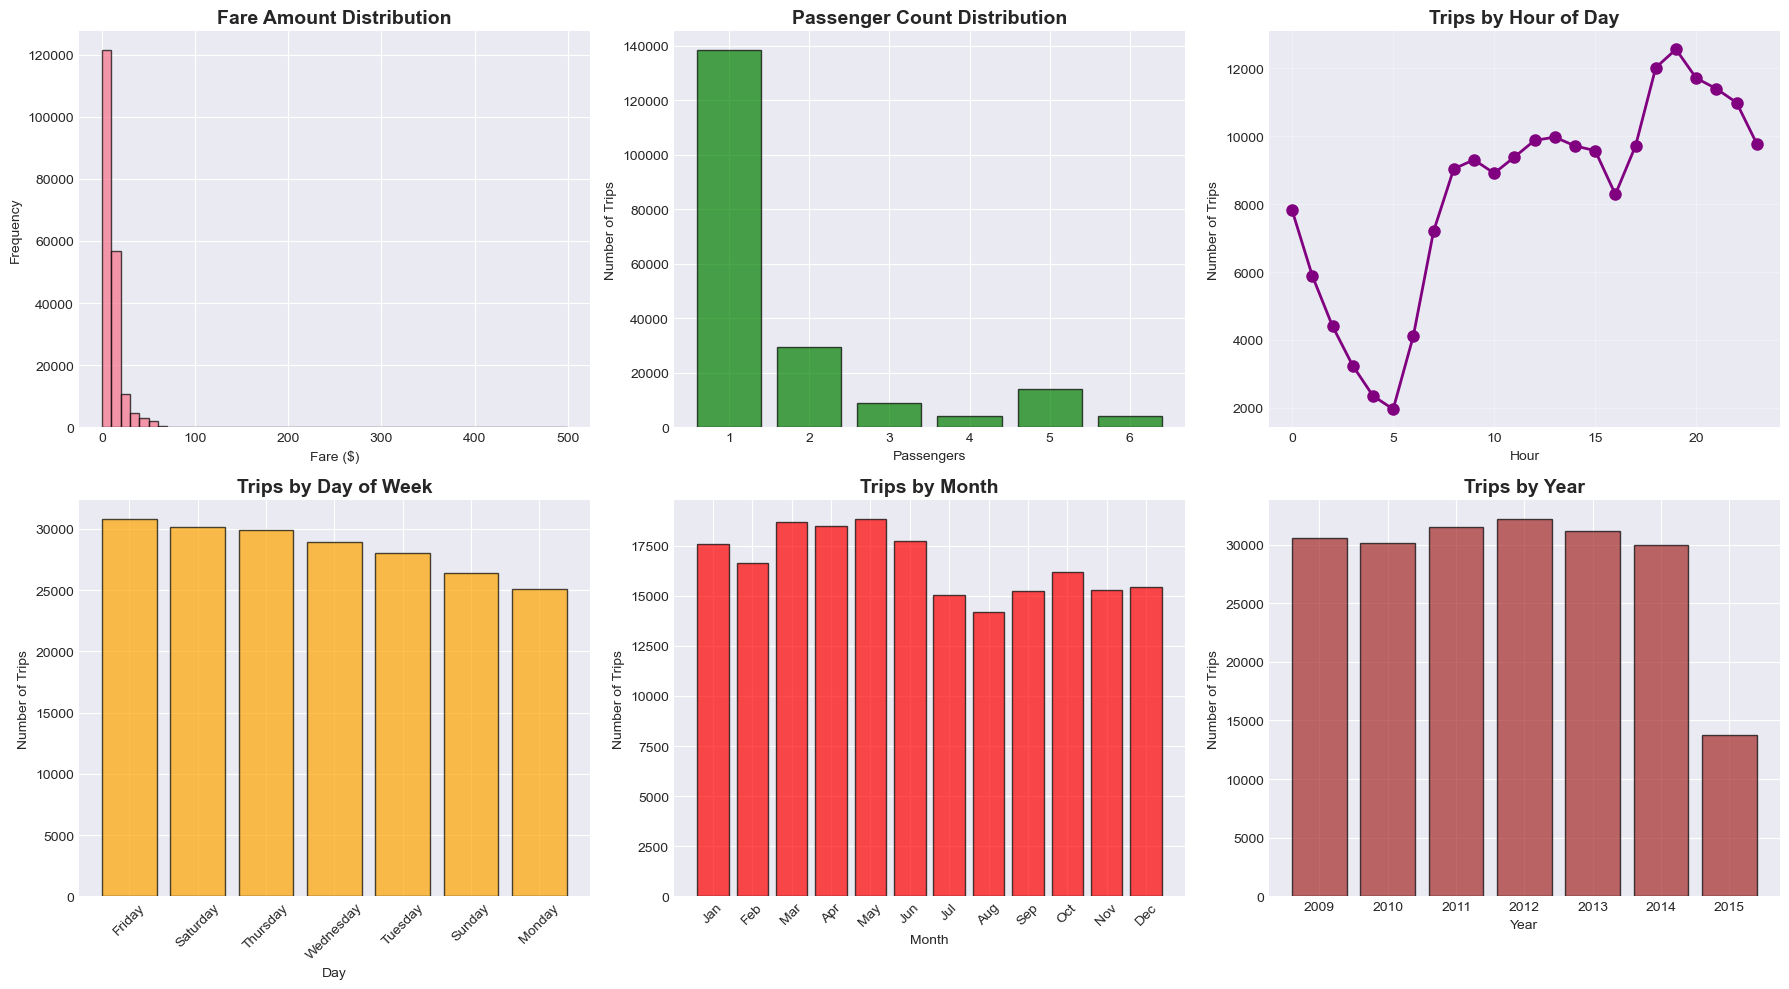

In [18]:
# Distribution of key variables
print("\n9. EXPLORATORY DATA ANALYSIS")

fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# Fare distribution
axes[0, 0].hist(df['fare_amount'], bins=50, edgecolor='black', alpha=0.7)
axes[0, 0].set_title('Fare Amount Distribution', fontsize=14, fontweight='bold')
axes[0, 0].set_xlabel('Fare ($)')
axes[0, 0].set_ylabel('Frequency')

# Passenger count distribution
passenger_counts = df['passenger_count'].value_counts().sort_index()
axes[0, 1].bar(passenger_counts.index, passenger_counts.values, edgecolor='black', alpha=0.7, color='green')
axes[0, 1].set_title('Passenger Count Distribution', fontsize=14, fontweight='bold')
axes[0, 1].set_xlabel('Passengers')
axes[0, 1].set_ylabel('Number of Trips')

# Hourly trips
hourly_trips = df['pickup_hour'].value_counts().sort_index()
axes[0, 2].plot(hourly_trips.index, hourly_trips.values, marker='o', linewidth=2, markersize=8, color='purple')
axes[0, 2].set_title('Trips by Hour of Day', fontsize=14, fontweight='bold')
axes[0, 2].set_xlabel('Hour')
axes[0, 2].set_ylabel('Number of Trips')
axes[0, 2].grid(True, alpha=0.3)

# Day of week trips
dow_trips = df['day_name'].value_counts()
axes[1, 0].bar(dow_trips.index, dow_trips.values, edgecolor='black', alpha=0.7, color='orange')
axes[1, 0].set_title('Trips by Day of Week', fontsize=14, fontweight='bold')
axes[1, 0].set_xlabel('Day')
axes[1, 0].set_ylabel('Number of Trips')
axes[1, 0].tick_params(axis='x', rotation=45)

# Month trips
month_trips = df['month_name'].value_counts()
month_order = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
month_trips = month_trips.reindex(month_order)
axes[1, 1].bar(month_trips.index, month_trips.values, edgecolor='black', alpha=0.7, color='red')
axes[1, 1].set_title('Trips by Month', fontsize=14, fontweight='bold')
axes[1, 1].set_xlabel('Month')
axes[1, 1].set_ylabel('Number of Trips')
axes[1, 1].tick_params(axis='x', rotation=45)

# Year trips
year_trips = df['pickup_year'].value_counts().sort_index()
axes[1, 2].bar(year_trips.index.astype(str), year_trips.values, edgecolor='black', alpha=0.7, color='brown')
axes[1, 2].set_title('Trips by Year', fontsize=14, fontweight='bold')
axes[1, 2].set_xlabel('Year')
axes[1, 2].set_ylabel('Number of Trips')

plt.tight_layout()
plt.show()


10. CORRELATION ANALYSIS
Using columns: ['fare_amount', 'passenger_count', 'pickup_hour', 'pickup_day', 'pickup_month', 'pickup_dayofweek', 'is_day', 'is_weekend', 'is_rush_hour']


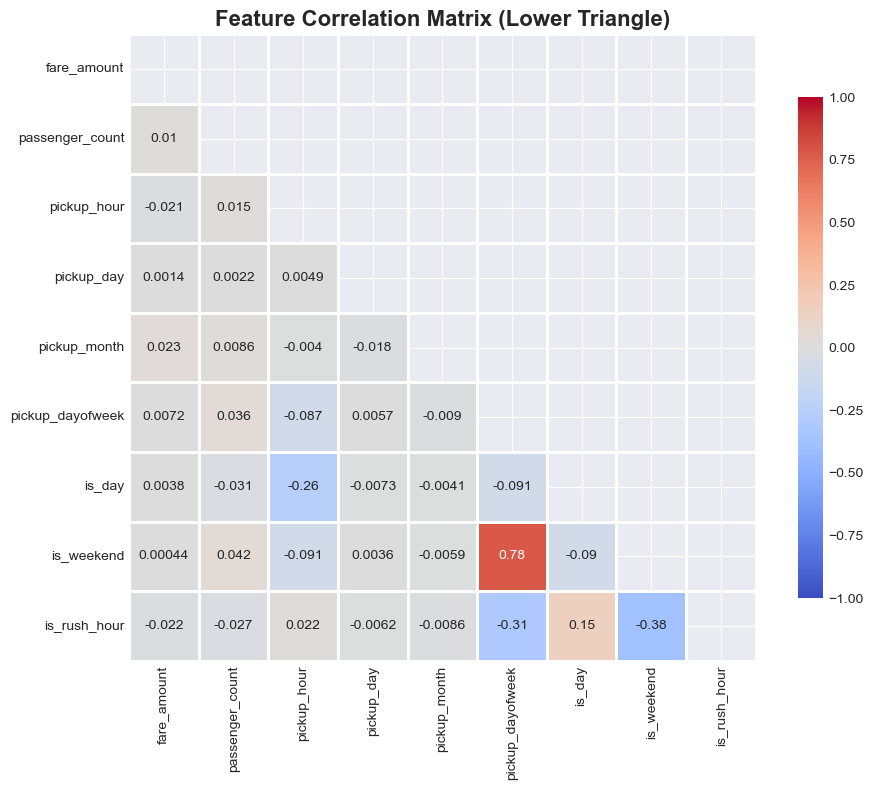


Top correlations with fare_amount:
fare_amount         1.000000
pickup_month        0.023496
passenger_count     0.010175
pickup_dayofweek    0.007231
is_day              0.003781
pickup_day          0.001416
is_weekend          0.000442
pickup_hour        -0.021460
is_rush_hour       -0.021856
Name: fare_amount, dtype: float64


In [19]:
# Correlation analysis
print("\n10. CORRELATION ANALYSIS")

# Select numerical columns for correlation
numerical_cols = ['fare_amount', 'passenger_count', 'pickup_hour', 'pickup_day', 
                  'pickup_month', 'pickup_dayofweek', 'is_day', 'is_weekend', 'is_rush_hour']

# Filter to only columns that exist
available_numerical_cols = [col for col in numerical_cols if col in df.columns]
print(f"Using columns: {available_numerical_cols}")

correlation_matrix = df[available_numerical_cols].corr()

# Create mask for upper triangle
mask = np.triu(np.ones_like(correlation_matrix, dtype=bool))

plt.figure(figsize=(10, 8))

# Plot heatmap with mask
sns.heatmap(correlation_matrix, 
            mask=mask,  # This masks the upper triangle
            annot=True, 
            cmap='coolwarm', 
            center=0, 
            square=True, 
            linewidths=1, 
            cbar_kws={"shrink": 0.8},
            vmin=-1, vmax=1)

plt.title('Feature Correlation Matrix (Lower Triangle)', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

print("\nTop correlations with fare_amount:")
if 'fare_amount' in correlation_matrix.columns:
    fare_corr = correlation_matrix['fare_amount'].sort_values(ascending=False)
    print(fare_corr)


11. AVERAGE FARE ANALYSIS


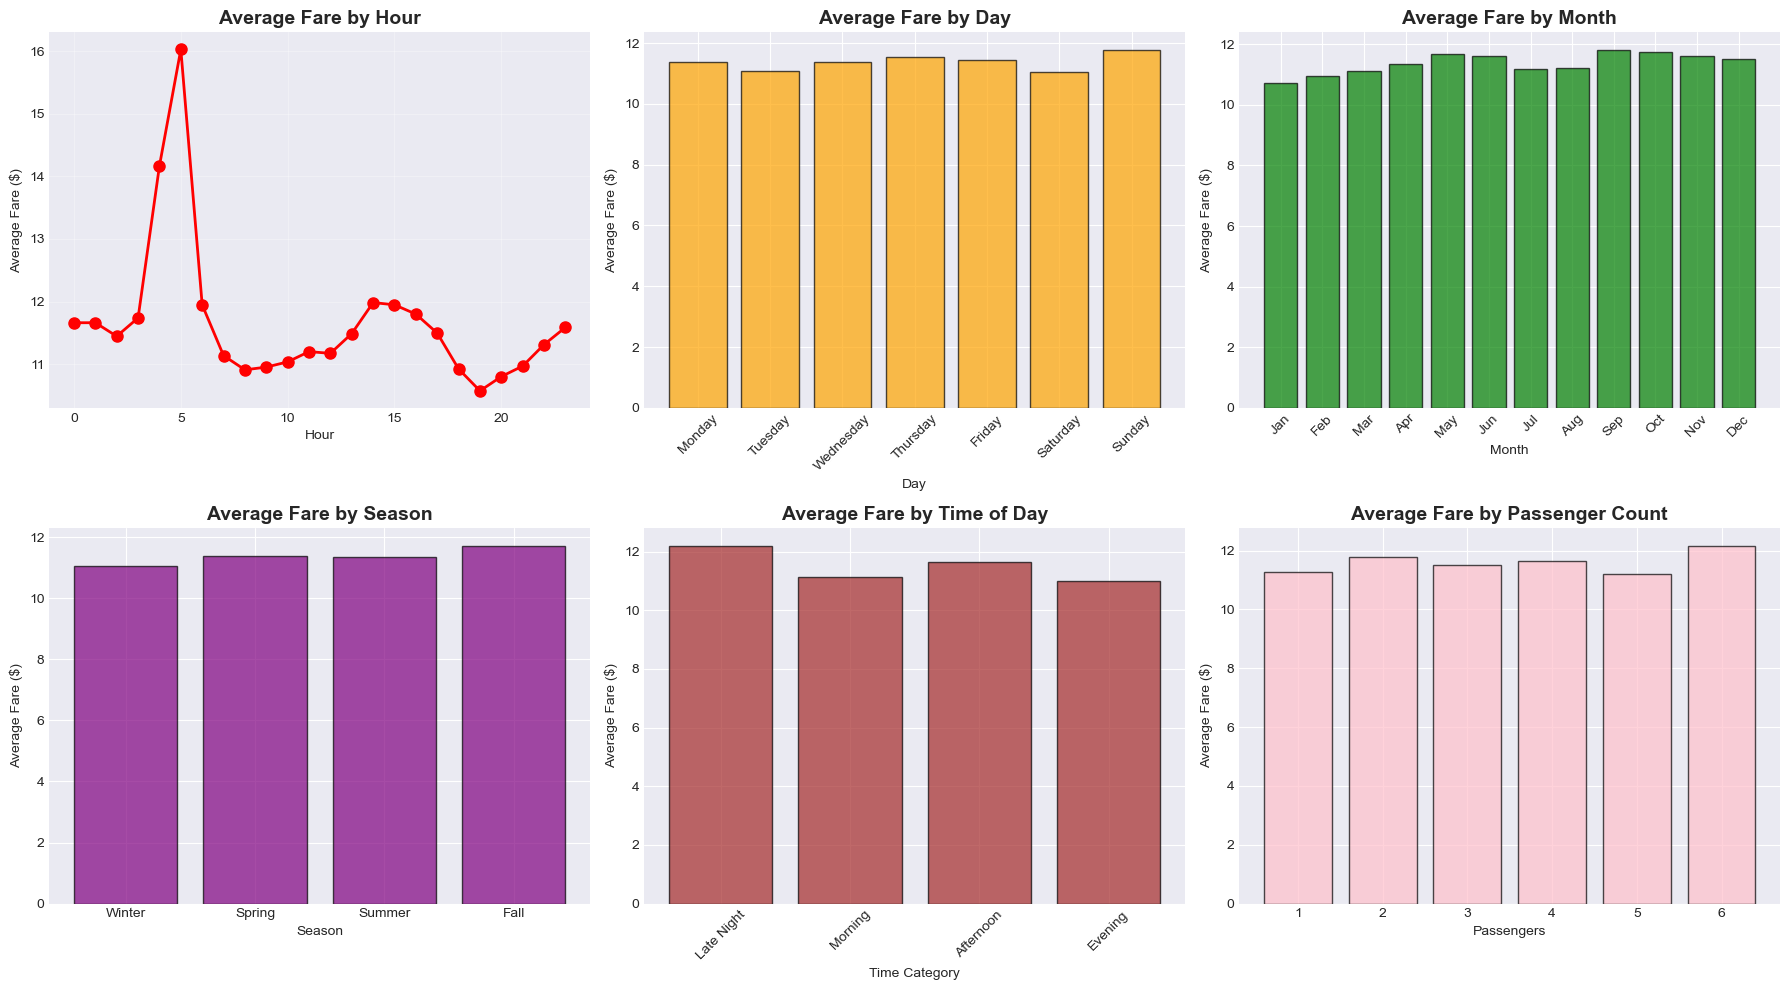

In [20]:
# Average fare by different categories
print("\n11. AVERAGE FARE ANALYSIS")

fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# By hour
hourly_avg_fare = df.groupby('pickup_hour')['fare_amount'].mean()
axes[0, 0].plot(hourly_avg_fare.index, hourly_avg_fare.values, marker='o', linewidth=2, markersize=8, color='red')
axes[0, 0].set_title('Average Fare by Hour', fontsize=14, fontweight='bold')
axes[0, 0].set_xlabel('Hour')
axes[0, 0].set_ylabel('Average Fare ($)')
axes[0, 0].grid(True, alpha=0.3)

# By day of week
if 'day_name' in df.columns:
    dow_avg_fare = df.groupby('day_name')['fare_amount'].mean()
    # Reorder days
    day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
    dow_avg_fare = dow_avg_fare.reindex(day_order)
    axes[0, 1].bar(dow_avg_fare.index, dow_avg_fare.values, edgecolor='black', alpha=0.7, color='orange')
    axes[0, 1].set_title('Average Fare by Day', fontsize=14, fontweight='bold')
    axes[0, 1].set_xlabel('Day')
    axes[0, 1].set_ylabel('Average Fare ($)')
    axes[0, 1].tick_params(axis='x', rotation=45)

# By month
if 'month_name' in df.columns:
    month_avg_fare = df.groupby('month_name')['fare_amount'].mean()
    month_order = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
    month_avg_fare = month_avg_fare.reindex(month_order)
    axes[0, 2].bar(month_avg_fare.index, month_avg_fare.values, edgecolor='black', alpha=0.7, color='green')
    axes[0, 2].set_title('Average Fare by Month', fontsize=14, fontweight='bold')
    axes[0, 2].set_xlabel('Month')
    axes[0, 2].set_ylabel('Average Fare ($)')
    axes[0, 2].tick_params(axis='x', rotation=45)

# By season
if 'season' in df.columns:
    season_avg_fare = df.groupby('season')['fare_amount'].mean()
    season_order = ['Winter', 'Spring', 'Summer', 'Fall']
    season_avg_fare = season_avg_fare.reindex(season_order)
    axes[1, 0].bar(season_avg_fare.index, season_avg_fare.values, edgecolor='black', alpha=0.7, color='purple')
    axes[1, 0].set_title('Average Fare by Season', fontsize=14, fontweight='bold')
    axes[1, 0].set_xlabel('Season')
    axes[1, 0].set_ylabel('Average Fare ($)')

# By hour category
if 'hour_category' in df.columns:
    hour_cat_avg_fare = df.groupby('hour_category')['fare_amount'].mean()
    # Ensure correct order
    cat_order = ['Late Night', 'Morning', 'Afternoon', 'Evening']
    hour_cat_avg_fare = hour_cat_avg_fare.reindex(cat_order)
    axes[1, 1].bar(hour_cat_avg_fare.index, hour_cat_avg_fare.values, edgecolor='black', alpha=0.7, color='brown')
    axes[1, 1].set_title('Average Fare by Time of Day', fontsize=14, fontweight='bold')
    axes[1, 1].set_xlabel('Time Category')
    axes[1, 1].set_ylabel('Average Fare ($)')
    axes[1, 1].tick_params(axis='x', rotation=45)

# By passenger count
pass_avg_fare = df.groupby('passenger_count')['fare_amount'].mean()
axes[1, 2].bar(pass_avg_fare.index, pass_avg_fare.values, edgecolor='black', alpha=0.7, color='pink')
axes[1, 2].set_title('Average Fare by Passenger Count', fontsize=14, fontweight='bold')
axes[1, 2].set_xlabel('Passengers')
axes[1, 2].set_ylabel('Average Fare ($)')

plt.tight_layout()
plt.show()